# Nuclear Escalation Rationale Coding Analysis

Analysis of qualitative codes assigned to nuclear escalation quotes, broken down by model configuration. Code frequencies are normalized by number of games each model played.

In [86]:
import sys
sys.path.insert(0, '../..')

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plot_utilities import setup_notebook_display, get_player_color, get_player_hatch, load_panel_data

setup_notebook_display(figsize=(14, 6))

In [87]:
# Rebuild game_counts cache from panel_data if missing
cache_path = 'coding/game_counts.csv'
if not os.path.exists(cache_path):
    panel = load_panel_data(csv_path='../../panel_data.csv', print_metadata=False)
    gc = panel.groupby('player_type')['game_id'].nunique().reset_index()
    gc.columns = ['player_type', 'game_count']
    gc.to_csv(cache_path, index=False)
    print(f'Rebuilt {cache_path} from panel_data.csv')

# Load coded quotes and cached game counts
df = pd.read_csv('coding/coded_quotes.csv')
game_counts = pd.read_csv(cache_path)

# Map short model keys to full names
MODEL_KEY_MAP = {
    'DS32B': 'Deepseek-3.2-Briefed',
    'DS32S': 'Deepseek-3.2-Simple',
    'GLM47B': 'GLM-4.7-Briefed',
    'GLM47S': 'GLM-4.7-Simple',
    'GPT120S': 'GPT-OSS-120B-Simple',
    'KK25B': 'Kimi-K2.5-Briefed',
    'KK25S': 'Kimi-K2.5-Simple',
}
df['Model'] = df['Model'].map(MODEL_KEY_MAP)

# Derive code columns dynamically (everything after metadata columns)
META_COLS = ['QuoteID', 'Model', 'Civ', 'Turn']
code_cols = [c for c in df.columns if c not in META_COLS]
CODE_NAMES = {c: c.replace(' ', '\n') for c in code_cols}

# Raw counts: model x code
raw_counts = df.groupby('Model')[code_cols].sum().astype(int)

# Normalize by game counts (filter to only models present in coded quotes)
games = game_counts.set_index('player_type')['game_count']
games = games.reindex(raw_counts.index)
norm_counts = raw_counts.div(games, axis=0)

print('Raw code counts by model:')
display(raw_counts)
print(f'\nNormalized (codes per game) — denominator = number of games played:')
display(norm_counts.style.format('{:.3f}'))

Raw code counts by model:


,Crisis Construction,Desperation,Deterrence,Offensive Conquest,Counter Non-Military Victory,Reactive Retaliatory,Normalization,Combined Arms,Total War Mobilization,Dual Track Strategy,Delegation Automation,Quantification Conditional,Technology Racing
Model,,,,,,,,,,,,,
Deepseek-3.2-Briefed,2,0,0,2,1,0,2,2,2,0,2,1,1
Deepseek-3.2-Simple,10,4,5,13,2,4,7,14,11,8,6,14,7
GLM-4.7-Briefed,2,2,0,2,2,0,0,2,2,1,0,2,2
GLM-4.7-Simple,8,5,5,3,2,7,7,8,8,3,8,8,7
GPT-OSS-120B-Simple,0,0,0,2,0,1,2,2,1,0,0,0,0
Kimi-K2.5-Briefed,10,5,3,6,6,2,2,7,6,3,3,7,5
Kimi-K2.5-Simple,26,17,7,15,13,8,4,16,16,9,3,18,19



Normalized (codes per game) — denominator = number of games played:


,Crisis Construction,Desperation,Deterrence,Offensive Conquest,Counter Non-Military Victory,Reactive Retaliatory,Normalization,Combined Arms,Total War Mobilization,Dual Track Strategy,Delegation Automation,Quantification Conditional,Technology Racing
Model,,,,,,,,,,,,,
Deepseek-3.2-Briefed,0.017,0.000,0.000,0.017,0.009,0.000,0.017,0.017,0.017,0.000,0.017,0.009,0.009
Deepseek-3.2-Simple,0.087,0.035,0.043,0.113,0.017,0.035,0.061,0.122,0.096,0.070,0.052,0.122,0.061
GLM-4.7-Briefed,0.011,0.011,0.000,0.011,0.011,0.000,0.000,0.011,0.011,0.006,0.000,0.011,0.011
GLM-4.7-Simple,0.045,0.028,0.028,0.017,0.011,0.040,0.040,0.045,0.045,0.017,0.045,0.045,0.040
GPT-OSS-120B-Simple,0.000,0.000,0.000,0.018,0.000,0.009,0.018,0.018,0.009,0.000,0.000,0.000,0.000
Kimi-K2.5-Briefed,0.082,0.041,0.025,0.049,0.049,0.016,0.016,0.057,0.049,0.025,0.025,0.057,0.041
Kimi-K2.5-Simple,0.213,0.139,0.057,0.123,0.107,0.066,0.033,0.131,0.131,0.074,0.025,0.148,0.156


## Code Frequency by Model (Normalized by Games Played)

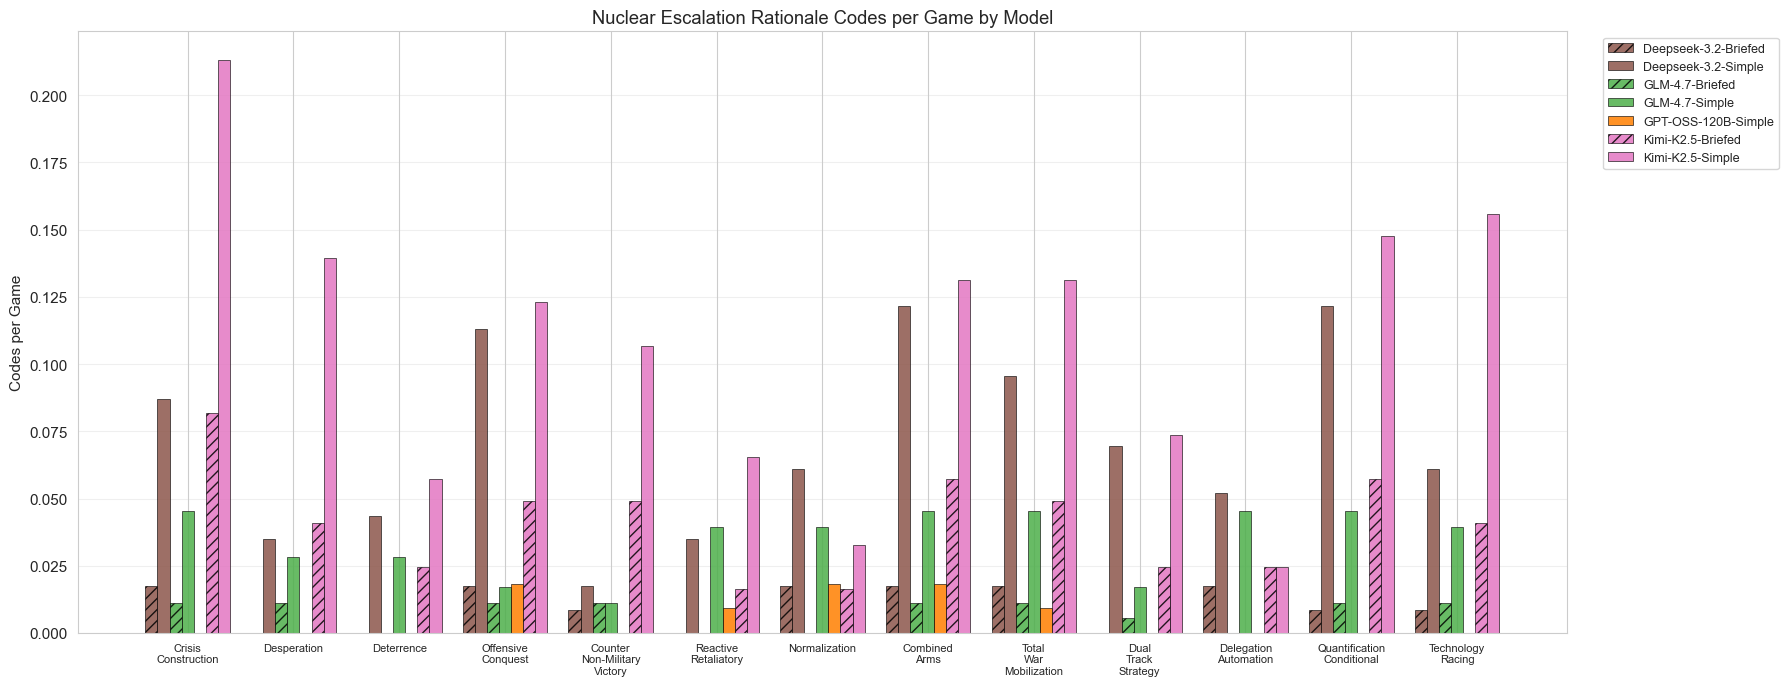

In [88]:
# Grouped bar chart: codes on x-axis, bars grouped by model
models = norm_counts.index.tolist()
n_models = len(models)
n_codes = len(code_cols)

fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.8 / n_models
x = np.arange(n_codes)

for i, model in enumerate(models):
    offset = (i - n_models / 2 + 0.5) * bar_width
    vals = norm_counts.loc[model].values
    color = get_player_color(model)
    hatch = get_player_hatch(model)
    ax.bar(x + offset, vals, bar_width, label=model,
           color=color, hatch=hatch, edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([CODE_NAMES[c] for c in code_cols], fontsize=8, ha='center')
ax.set_ylabel('Codes per Game')
ax.set_title('Nuclear Escalation Rationale Codes per Game by Model')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

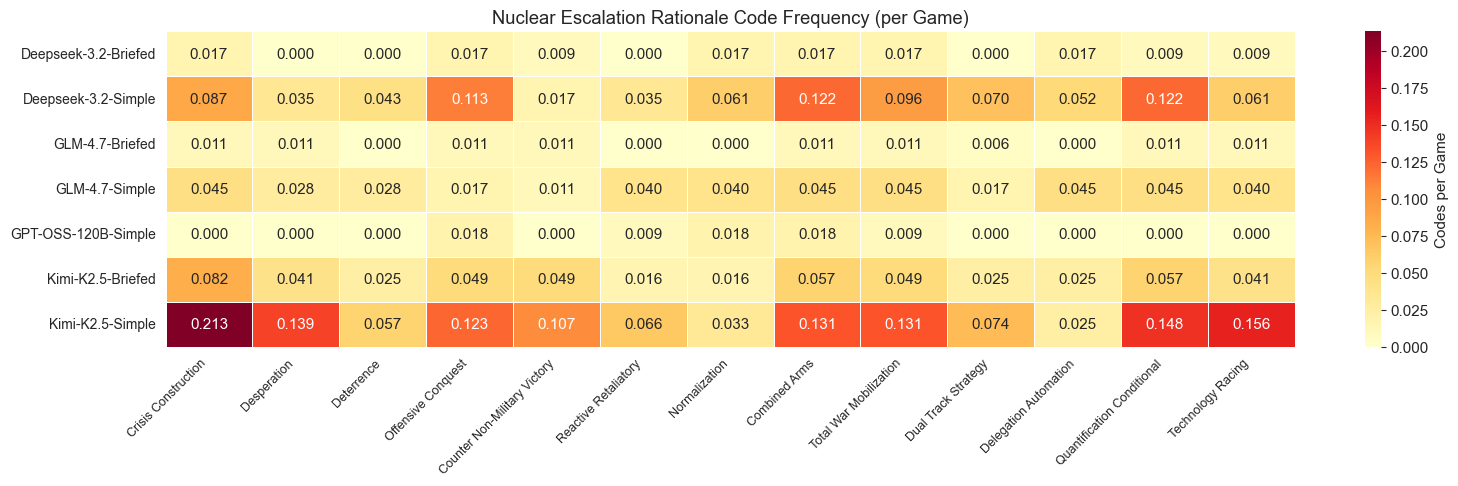

In [89]:
# Heatmap: model x code (normalized)
fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(norm_counts, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Codes per Game'})
ax.set_title('Nuclear Escalation Rationale Code Frequency (per Game)')
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## Real-World Reframing Experiment

To test whether nuclear escalation decisions were artifacts of game framing, we replayed 72 nuclear escalation turns with prompts reframed from game language to real-world geopolitical decision-making. All other context (military situation, resources, diplomacy) was preserved.

**Key finding**: No model decreased its UseNuke value — scores either stayed the same or increased when reframed as real-world decisions.

In [90]:
from plot_utilities import get_player_marker

# Load replay results
replay_df = pd.read_csv('replay/nuke-real-world-v1-results.csv')
replay_df['delta'] = replay_df['replayUseNuke'] - replay_df['beforeUseNuke']

# Summary table by model
summary = replay_df.groupby('player_type').agg(
    n=('delta', 'size'),
    mean_before=('beforeUseNuke', 'mean'),
    mean_after=('replayUseNuke', 'mean'),
    mean_delta=('delta', 'mean'),
    pct_unchanged=('delta', lambda x: (x == 0).mean() * 100)
).round(1)
summary.columns = ['n', 'Mean Before', 'Mean After', 'Mean Δ', '% Unchanged']
display(summary)

,n,Mean Before,Mean After,Mean Δ,% Unchanged
player_type,,,,,
Deepseek-3.2-Briefed,2,70.0,75.0,5.0,50.0
Deepseek-3.2-Simple,20,62.8,69.0,6.2,55.0
GLM-4.7-Briefed,2,87.5,90.0,2.5,50.0
GLM-4.7-Simple,8,86.6,88.2,1.6,75.0
GPT-OSS-120B-Simple,2,85.0,85.0,0.0,100.0
Kimi-K2.5-Briefed,11,48.6,57.7,9.1,90.9
Kimi-K2.5-Simple,27,75.5,82.1,6.7,77.8


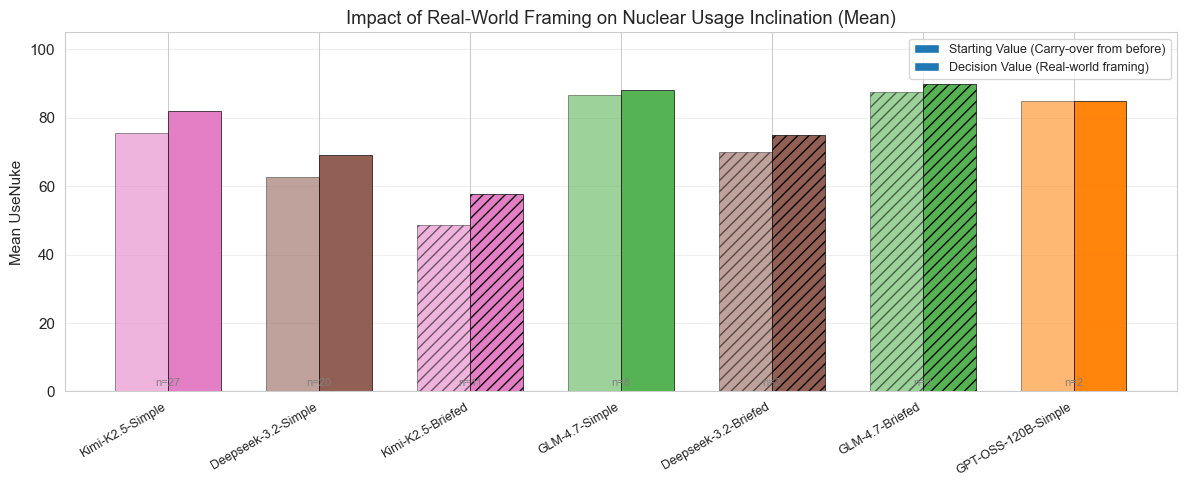

In [91]:
# Grouped bar chart: mean UseNuke before vs after by model
models = summary.sort_values('n', ascending=False).index.tolist()
x = np.arange(len(models))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

for i, model in enumerate(models):
    color = get_player_color(model)
    hatch = get_player_hatch(model)
    ax.bar(x[i] - bar_width/2, summary.loc[model, 'Mean Before'], bar_width,
           color=color, hatch=hatch, edgecolor='black', linewidth=0.5, alpha=0.55)
    ax.bar(x[i] + bar_width/2, summary.loc[model, 'Mean After'], bar_width,
           color=color, hatch=hatch, edgecolor='black', linewidth=0.5, alpha=0.95)

# Legend entries for before/after
ax.bar([], [], bar_width, color='gray', alpha=0.55, edgecolor='black', label='Starting Value (Carry-over from before)')
ax.bar([], [], bar_width, color='gray', alpha=0.95, edgecolor='black', label='Decision Value (Real-world framing)')

# Annotate sample sizes
for i, model in enumerate(models):
    n = int(summary.loc[model, 'n'])
    ax.text(x[i], 1, f'n={n}', ha='center', va='bottom', fontsize=8, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean UseNuke')
ax.set_title('Impact of Real-World Framing on Nuclear Usage Inclination (Mean)')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

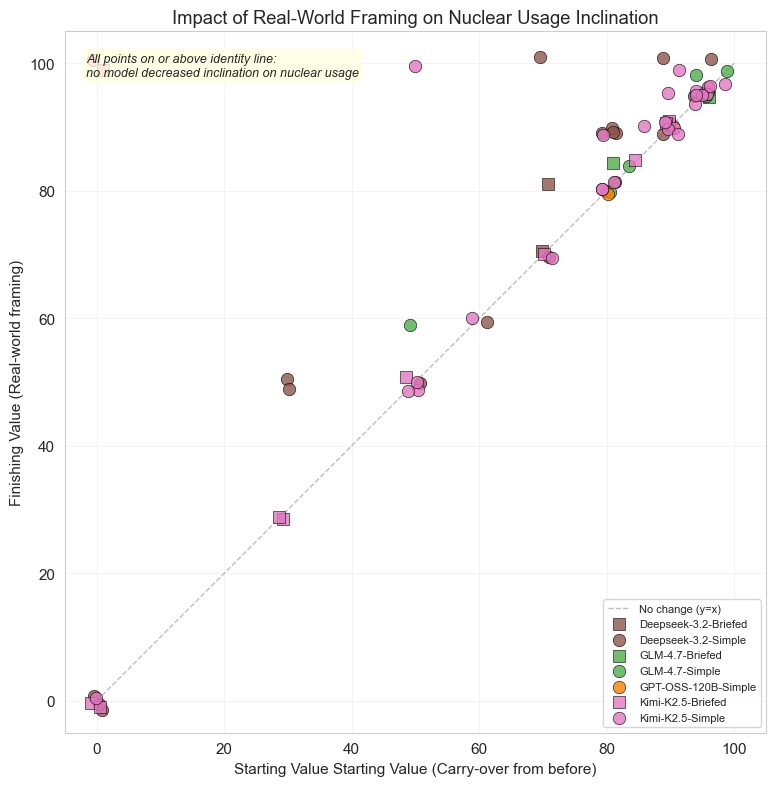

In [92]:
fig, ax = plt.subplots(figsize=(8, 8))

# Identity line
ax.plot([0, 100], [0, 100], '--', color='gray', alpha=0.5, linewidth=1, label='No change (y=x)')

# Jitter to avoid overplotting
rng = np.random.default_rng(42)
jitter = 1.5

for model in sorted(replay_df['player_type'].unique()):
    subset = replay_df[replay_df['player_type'] == model]
    jx = rng.uniform(-jitter, jitter, len(subset))
    jy = rng.uniform(-jitter, jitter, len(subset))
    ax.scatter(
        subset['beforeUseNuke'] + jx,
        subset['replayUseNuke'] + jy,
        c=get_player_color(model),
        marker=get_player_marker(model),
        s=80, alpha=0.8, edgecolors='black', linewidths=0.5,
        label=model, zorder=3
    )

ax.set_xlabel('Starting Value Starting Value (Carry-over from before)')
ax.set_ylabel('Finishing Value (Real-world framing)')
ax.set_title('Impact of Real-World Framing on Nuclear Usage Inclination')
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='lower right')
ax.annotate('All points on or above identity line:\nno model decreased inclination on nuclear usage',
            xy=(0.03, 0.97), xycoords='axes fraction', va='top',
            fontsize=9, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [93]:
from scipy.stats import wilcoxon

delta = replay_df['delta']
n_total = len(delta)
n_unchanged = (delta == 0).sum()
n_increased = (delta > 0).sum()

print(f'Total observations: {n_total}')
print(f'Unchanged: {n_unchanged} ({n_unchanged/n_total*100:.1f}%)')
print(f'Increased: {n_increased} ({n_increased/n_total*100:.1f}%)')
print(f'Decreased: {(delta < 0).sum()}')
print(f'Mean increase (among changed): {delta[delta != 0].mean():.1f}')
print()

# Wilcoxon signed-rank test (paired, one-sided: real-world >= game)
stat, p = wilcoxon(replay_df['beforeUseNuke'], replay_df['replayUseNuke'],
                   alternative='less', zero_method='wilcox')
print(f'Wilcoxon signed-rank test (one-sided: before < after):')
print(f'  Statistic = {stat:.1f}, p = {p:.4f}')
print(f'  {"Significant" if p < 0.05 else "Not significant"} at α = 0.05')

Total observations: 72
Unchanged: 52 (72.2%)
Increased: 20 (27.8%)
Decreased: 0
Mean increase (among changed): 21.6

Wilcoxon signed-rank test (one-sided: before < after):
  Statistic = 0.0, p = 0.0000
  Significant at α = 0.05
